# PCA & K-Means Clustering — Medical Device Sector
### Unsupervised Factor Analysis on Quarterly Bloomberg Fundamentals

---

## Objective

This notebook applies **Principal Component Analysis (PCA)** and **K-Means clustering**
to quarterly Bloomberg fundamental data for 11 medical device companies,
answering two core questions for the investment thesis:

1. **What latent factors** explain the cross-sectional variance in fundamentals each quarter —
   and which raw metrics drive those factors?
2. **How do companies cluster** over time — and do clusters stay stable, or do companies
   migrate between peer groups as business fundamentals evolve?

---

## Analytical Pipeline

| Step | Technique | Output |
|------|-----------|--------|
| 1 | Load & reshape quarterly data | `quarter_dict`: one DataFrame per quarter, rows = tickers, columns = features |
| 2 | PCA per quarter | Explained variance over time; top feature loadings driving PC1 |
| 3 | Company PC1 trajectory | How each firm's factor score evolves quarter-by-quarter |
| 4 | K-Means clustering (k=3) on PC1/PC2 | Peer groups based on latent factors, not raw metrics |
| 5 | Cluster stability analysis | Which companies hold their position vs. migrate between groups |
| 6 | Animated cluster evolution | GIF visualising group dynamics over the full sample period |

**Data:** Bloomberg Terminal quarterly fundamentals  
**Universe:** ABT, MDT, BSX, DXCM, TMO, BDX, EW, PODD, ITGR, MMSI, ZBH  
**Helper module:** `functions_preprocessing.py` (data reshaping, PCA runner, clustering, plot utilities)


## 1. Imports

Standard scientific stack plus `sklearn` for PCA and K-Means, `statsmodels` for optional
regression diagnostics, and the project-level `functions_preprocessing` module that
contains all data-wrangling and plotting helpers.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.animation as animation
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')



## Helper Functions

The functions below are the full implementation of the analytical pipeline.
They are defined here inline so the notebook is **completely self-contained** —
no external module needed.

| Function | Purpose |
|----------|---------|
| `assemble_dataframe` | Pivots the `{feature: DataFrame}` dict into a long-format tidy DataFrame |
| `make_quarter_dict` | Slices the tidy DataFrame into `{quarter: tickers×features}` matrices |
| `run_pca_per_quarter` | Runs StandardScaler + PCA independently on each quarter's cross-section |
| `plot_pca_results` | Line chart of explained variance per PC across quarters |
| `collect_top_contributors` | Extracts top-N feature loadings per PC per quarter |
| `plot_feature_contributions` | Time-series of which fundamentals drive PC1 each quarter |
| `plot_company_pc1` | Plots a single company's PC1 score trajectory over time |
| `run_clustering_on_pca` | K-Means on PC scores per quarter, returns cluster assignments |
| `create_animated_clustering` | Saves an animated GIF of companies moving in PC1/PC2 space |
| `analyze_cluster_stability` | Computes each company's stability ratio across quarters |
| `plot_cluster_transitions` | Heatmap of cluster membership over time (companies × quarters) |


In [2]:
def assemble_dataframe(fundamentals: dict) -> pd.DataFrame:
    """
    Convert a dictionary of {feature: DataFrame} into one big DataFrame.
    Each input DataFrame must have index=quarters, columns=tickers.

    Returns:
        pd.DataFrame with columns [quarter, ticker, feature1, feature2, ...]
    """
    long_dfs = []
    for feature, df in fundamentals.items():
        stacked = df.stack().reset_index()
        stacked.columns = ["quarter", "ticker", feature]
        long_dfs.append(stacked)

    big_df = long_dfs[0]
    for df in long_dfs[1:]:
        big_df = big_df.merge(df, on=["quarter", "ticker"], how="outer")

    return big_df


def make_quarter_dict(fundamentals: dict) -> dict:
    """
    Convert a dictionary of {feature: DataFrame} into a dictionary keyed by quarter.
    Each resulting DataFrame has rows=tickers, cols=features.

    Returns:
        dict: {quarter: DataFrame(stocks × features)}
    """
    big_df = assemble_dataframe(fundamentals)

    quarter_dict = {}
    for q, group in big_df.groupby("quarter"):
        # Drop the 'quarter' column, index = ticker, columns = features
        pivoted = group.drop(columns="quarter").set_index("ticker")
        quarter_dict[q] = pivoted

    return quarter_dict


def run_pca_per_quarter(quarter_dict: dict, n_components: int = 3):
    """
    Run PCA on each quarter's dataframe (stocks × features), normalizing features first.

    Args:
        quarter_dict: dict of {quarter: DataFrame(tickers × features)}
        n_components: number of principal components to keep

    Returns:
        results: dict of {quarter: {"pca": PCA object,
                                    "explained_variance": array,
                                    "loadings": DataFrame,
                                    "scores": DataFrame}}
    """
    results = {}

    for quarter, df in quarter_dict.items():
        # Drop rows with NaN
        clean_df = df.dropna()
        if clean_df.shape[0] < n_components:
            continue  # skip if not enough stocks

        # Normalize features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(clean_df)

        # Fit PCA
        pca = PCA(n_components=n_components)
        scores = pca.fit_transform(X_scaled)

        # Create loadings dataframe
        loadings = pd.DataFrame(
            pca.components_.T,
            index=clean_df.columns,
            columns=[f"PC{i+1}" for i in range(n_components)]
        )

        # Create scores dataframe (stocks × PCs)
        scores_df = pd.DataFrame(
            scores,
            index=clean_df.index,  # ticker names
            columns=[f"PC{i+1}" for i in range(n_components)]
        )

        # Store results
        results[quarter] = {
            "pca": pca,
            "explained_variance": pca.explained_variance_ratio_,
            "loadings": loadings,
            "scores": scores_df
        }

    return results


def plot_pca_results(pca_results: dict, n_components: int = 3):
    """
    Plot explained variance and loadings for each quarter.
    """
    quarters = list(pca_results.keys())
    ev_matrix = [pca_results[q]["explained_variance"] for q in quarters]

    # --- Plot explained variance over time ---
    plt.figure(figsize=(10, 5))
    for i in range(n_components):
        plt.plot(quarters, [ev[i] if i < len(ev) else 0 for ev in ev_matrix],
                 marker="o", label=f"PC{i + 1}")
    plt.title("Explained Variance by Quarter")
    plt.xlabel("Quarter")
    plt.ylabel("Variance Explained")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def collect_top_contributors(pca_results: dict, n_components: int = 3, top_n: int = 3):
    """
    Collect top contributing features for each PC over time.

    Returns:
        DataFrame with columns: quarter, PC, feature, loading
    """
    records = []
    for q, res in pca_results.items():
        loadings = res["loadings"]
        for pc in loadings.columns[:n_components]:
            # Take top N absolute loadings
            top_features = loadings[pc].abs().sort_values(ascending=False).head(top_n)
            for feature in top_features.index:
                records.append({
                    "quarter": q,
                    "PC": pc,
                    "feature": feature,
                    "loading": loadings.loc[feature, pc]
                })
    return pd.DataFrame(records)


def plot_feature_contributions(contrib_df: pd.DataFrame, pc="PC1"):
    """
    Plot loadings of top features over time for a given PC.
    """
    df_pc = contrib_df[contrib_df["PC"] == pc]
    plt.figure(figsize=(10, 5))
    for feature in df_pc["feature"].unique():
        sub = df_pc[df_pc["feature"] == feature]
        plt.plot(sub["quarter"], sub["loading"], marker="o", label=feature)
    plt.axhline(0, color="black", linestyle="--", alpha=0.7)
    plt.title(f"Top Feature Loadings for {pc} Over Time")
    plt.xlabel("Quarter")
    plt.ylabel("Loading")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_company_pc1(pca_results: dict, target: str):
    quarters, scores = [], []
    for q, res in pca_results.items():
        if target in res["scores"].index:
            quarters.append(q)
            scores.append(res["scores"].loc[target, "PC1"])

    plt.figure(figsize=(10, 5))
    plt.plot(quarters, scores, marker="o", label=target, linewidth=2)
    plt.axhline(0, color="black", linestyle="--", alpha=0.7)
    plt.title(f"PC1 Score Over Time: {target}")
    plt.xlabel("Quarter")
    plt.ylabel("PC1 Score (Size Factor)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_clustering_on_pca(pca_results: dict, n_clusters: int = 3, 
                         use_components: list = [1, 2]):
    """
    Run K-means clustering on PCA scores for each quarter.
    
    Args:
        pca_results: Results from run_pca_per_quarter()
        n_clusters: Number of clusters for K-means
        use_components: Which principal components to use (1-indexed, e.g., [1, 2] for PC1 and PC2)
        
    Returns:
        clustering_results: dict with clustering info for each quarter
    """
    clustering_results = {}
    
    for quarter, pca_data in pca_results.items():
        scores_df = pca_data["scores"]
        
        # Select which components to use (convert to column names)
        component_cols = [f"PC{i}" for i in use_components]
        clustering_data = scores_df[component_cols].values
        
        # Perform K-means clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(clustering_data)
        
        # Store clustering results
        clustering_results[quarter] = {
            "scores": scores_df,
            "clusters": clusters,
            "cluster_centers": kmeans.cluster_centers_,
            "tickers": scores_df.index.tolist(),
            "explained_variance": pca_data["explained_variance"],
            "loadings": pca_data["loadings"]
        }
    
    return clustering_results


def create_animated_clustering(clustering_results: dict, use_components: list = [1, 2], 
                              save_path: str = 'clustering_animation.gif', 
                              interval: int = 1500,
                              show_loadings: bool = True):
    """
    Create animated plot showing cluster evolution over time.
    
    Args:
        clustering_results: Results from run_clustering_on_pca()
        use_components: Which PCs to plot (1-indexed)
        save_path: Where to save the animation
        interval: Time between frames in milliseconds
        show_loadings: Whether to show loadings plot alongside clusters
    """
    # Set up figure
    if show_loadings:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    else:
        fig, ax1 = plt.subplots(figsize=(10, 7))
        ax2 = None
    
    quarters = sorted(clustering_results.keys())
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', 
              '#1abc9c', '#e67e22', '#95a5a6', '#34495e', '#d35400']
    
    pc_cols = [f"PC{i}" for i in use_components]
    
    def animate(frame):
        ax1.clear()
        if ax2 is not None:
            ax2.clear()
        
        quarter = quarters[frame]
        data = clustering_results[quarter]
        
        scores_df = data["scores"]
        clusters = data["clusters"]
        tickers = data["tickers"]
        explained_var = data["explained_variance"]
        
        # Plot 1: Clustering scatter
        for cluster_id in range(max(clusters) + 1):
            mask = clusters == cluster_id
            if np.any(mask):
                cluster_data = scores_df.loc[mask, pc_cols]
                ax1.scatter(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1], 
                          c=colors[cluster_id % len(colors)], 
                          label=f'Cluster {cluster_id}',
                          s=150, alpha=0.7, edgecolors='black', linewidth=1.5)
                
                # Add labels
                for idx in cluster_data.index:
                    label = idx.replace(' US Equity', '').replace(' Equity', '')
                    ax1.annotate(label, 
                               (cluster_data.loc[idx, pc_cols[0]], 
                                cluster_data.loc[idx, pc_cols[1]]),
                               xytext=(5, 5), textcoords='offset points',
                               fontsize=9, fontweight='bold')
        
        pc1_var = explained_var[use_components[0]-1]
        pc2_var = explained_var[use_components[1]-1]
        
        ax1.set_xlabel(f'{pc_cols[0]} ({pc1_var:.1%} variance)', fontsize=12, fontweight='bold')
        ax1.set_ylabel(f'{pc_cols[1]} ({pc2_var:.1%} variance)', fontsize=12, fontweight='bold')
        ax1.set_title(f'Company Clustering - {quarter}', fontsize=14, fontweight='bold', pad=15)
        ax1.legend(loc='best', fontsize=10)
        ax1.grid(True, alpha=0.3, linestyle='--')
        
        # Set consistent limits
        all_pc1 = np.concatenate([clustering_results[q]["scores"][pc_cols[0]].values 
                                 for q in quarters])
        all_pc2 = np.concatenate([clustering_results[q]["scores"][pc_cols[1]].values 
                                 for q in quarters])
        margin = 0.5
        ax1.set_xlim(all_pc1.min() - margin, all_pc1.max() + margin)
        ax1.set_ylim(all_pc2.min() - margin, all_pc2.max() + margin)
        
        # Plot 2: Feature loadings (if enabled)
        if ax2 is not None:
            loadings = data["loadings"][pc_cols]
            
            for idx, feature in enumerate(loadings.index):
                x, y = loadings.iloc[idx, 0], loadings.iloc[idx, 1]
                ax2.arrow(0, 0, x, y, head_width=0.04, head_length=0.05, 
                         fc='darkblue', ec='darkblue', alpha=0.8, linewidth=2)
                ax2.text(x * 1.15, y * 1.15, feature, 
                        fontsize=9, ha='center', va='center', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', 
                                alpha=0.7, edgecolor='black'))
            
            ax2.set_xlabel(f'{pc_cols[0]} Loadings', fontsize=12, fontweight='bold')
            ax2.set_ylabel(f'{pc_cols[1]} Loadings', fontsize=12, fontweight='bold')
            ax2.set_title('Feature Contributions', fontsize=14, fontweight='bold', pad=15)
            ax2.grid(True, alpha=0.3, linestyle='--')
            ax2.set_xlim(-1.1, 1.1)
            ax2.set_ylim(-1.1, 1.1)
            
            circle = plt.Circle((0, 0), 1, fill=False, color='gray', 
                              linestyle='--', alpha=0.5, linewidth=2)
            ax2.add_patch(circle)
            ax2.axhline(0, color='k', linewidth=0.5, alpha=0.3)
            ax2.axvline(0, color='k', linewidth=0.5, alpha=0.3)
    
    ani = animation.FuncAnimation(fig, animate, frames=len(quarters), 
                                 interval=interval, repeat=True, blit=False)
    
    ani.save(save_path, writer='pillow', fps=1000/interval)
    plt.tight_layout()
    plt.show()
    
    return ani


def analyze_cluster_stability(clustering_results: dict):
    """
    Analyze cluster stability over time.
    """
    quarters = sorted(clustering_results.keys())
    company_history = {}
    
    for quarter in quarters:
        tickers = clustering_results[quarter]['tickers']
        clusters = clustering_results[quarter]['clusters']
        
        for ticker, cluster in zip(tickers, clusters):
            if ticker not in company_history:
                company_history[ticker] = []
            company_history[ticker].append((quarter, cluster))
    
    stability_metrics = {}
    for ticker, history in company_history.items():
        changes = sum(1 for i in range(1, len(history)) 
                     if history[i][1] != history[i-1][1])
        
        stability_metrics[ticker] = {
            'total_periods': len(history),
            'cluster_changes': changes,
            'stability_ratio': 1 - (changes / max(1, len(history) - 1)) if len(history) > 1 else 1.0
        }
    
    return stability_metrics


def plot_cluster_transitions(clustering_results: dict):
    """
    Create heatmap showing cluster transitions over time.
    """
    quarters = sorted(clustering_results.keys())
    all_tickers = set()
    
    for data in clustering_results.values():
        all_tickers.update(data['tickers'])
    
    all_tickers = sorted(list(all_tickers))
    cluster_matrix = []
    
    for quarter in quarters:
        quarter_map = dict(zip(clustering_results[quarter]['tickers'], 
                             clustering_results[quarter]['clusters']))
        row = [quarter_map.get(ticker, -1) for ticker in all_tickers]
        cluster_matrix.append(row)
    
    labels = [t.replace(' US Equity', '').replace(' Equity', '') for t in all_tickers]
    cluster_df = pd.DataFrame(cluster_matrix, 
                             index=[str(q) for q in quarters], 
                             columns=labels)
    
    plt.figure(figsize=(14, 8))
    sns.heatmap(cluster_df.T, annot=True, fmt='d', cmap='tab10', 
                cbar_kws={'label': 'Cluster'}, linewidths=0.5)
    plt.title('Company Cluster Membership Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Quarter', fontsize=12)
    plt.ylabel('Companies', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return cluster_df




## 2. Data Loading & Preprocessing

Quarterly Bloomberg data is read from `Quarterly_Clean.xlsx` (all sheets at once).
The `make_quarter_dict` helper then **pivots** the data into a dictionary keyed by quarter —
each entry is a matrix of shape `(n_tickers × n_features)`, ready for cross-sectional PCA.

This quarterly slicing is key: rather than fitting one PCA on the full time series,
we fit an independent PCA **per quarter**, letting us track how the factor structure
and company groupings evolve over time.


In [3]:
base_dir = Path("~/Desktop/projects/quantitative_analysis/")
file_path = base_dir / "data/Quarterly_Clean.xlsx"

data = pd.read_excel(
    file_path,
    sheet_name=None,
    index_col="Date",
    parse_dates=["Date"]
)

quarter_dict = make_quarter_dict(data)
print(f"Loaded {len(quarter_dict)} quarters of data.")
print(f"Sample quarter shape (tickers × features): {list(quarter_dict.values())[0].shape}")


Loaded 24 quarters of data.
Sample quarter shape (tickers × features): (11, 25)


## 3. PCA — Rolling Quarter-by-Quarter Factor Analysis

PCA is run independently on each quarter's cross-sectional matrix.
Features are **z-score standardised** before decomposition so that no single metric
dominates simply due to scale.

**What the plots show:**

| Chart | Interpretation |
|-------|----------------|
| **Explained variance per quarter** | How much of the total cross-sectional variance PC1 (and PC2, PC3) captures each quarter. A rising R² means companies are becoming *more differentiated* on the first factor. |
| **Top feature loadings (PC1)** | Which raw fundamentals (e.g. ROE, revenue growth, margins) load most heavily onto the first principal component over time — i.e. what the market is 'pricing' in peer comparisons. |
| **Company PC1 trajectory** | A single company's PC1 score plotted quarter-by-quarter — showing whether its relative position is improving, declining, or stable. |


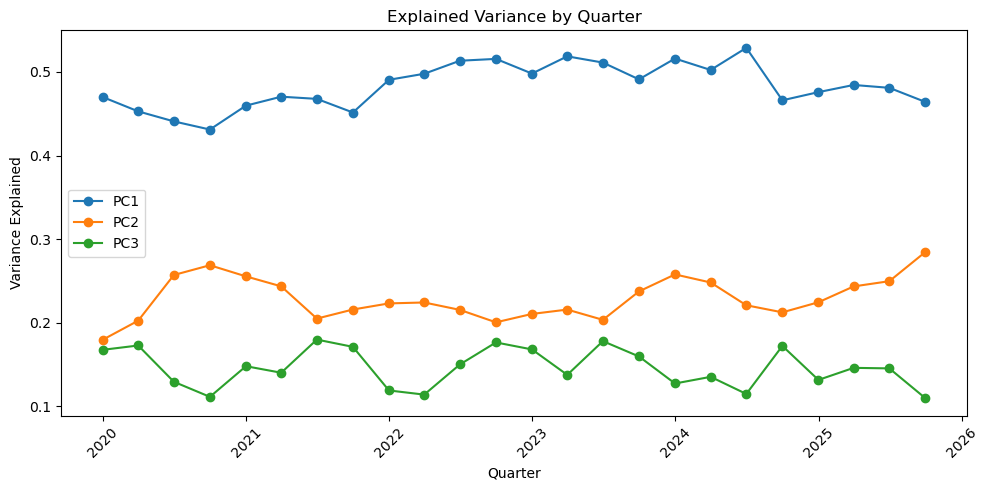

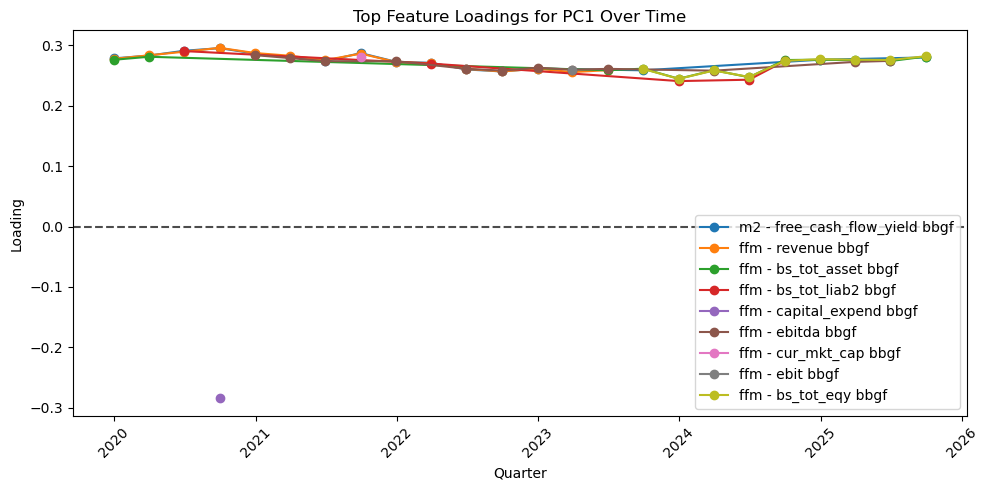

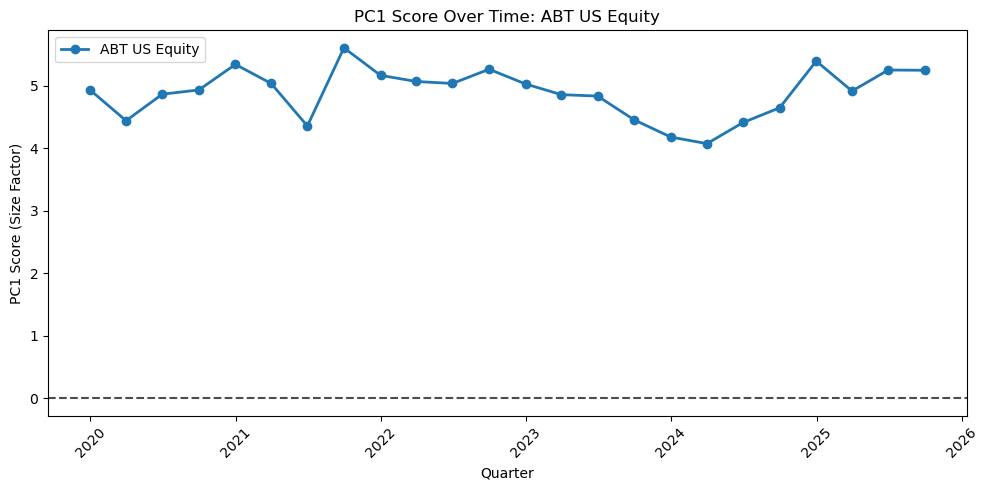

In [4]:
# Run PCA with 3 components across all quarters
pca_results = run_pca_per_quarter(quarter_dict, n_components=3)

# Plot explained variance over time (per quarter)
plot_pca_results(pca_results, n_components=3)

# Identify which features drive PC1 each quarter
contrib_df = collect_top_contributors(pca_results)
plot_feature_contributions(contrib_df, pc="PC1")

# Track a specific company's PC1 score over time
# Change target ticker below to any company in the universe
plot_company_pc1(pca_results, target="ABT US Equity")


## 4. K-Means Clustering on PCA Scores

Rather than clustering on raw fundamentals (which have different units and scales),
we cluster on the **PC1 and PC2 scores** from the PCA step.
This means we are grouping companies by their position in *latent factor space* —
a cleaner and more interpretable peer grouping than ad-hoc metric selection.

**K = 3 clusters** — chosen to broadly capture: quality/growth leaders, mid-tier, and laggards.

**What the plots show:**

| Output | Interpretation |
|--------|----------------|
| **Cluster transition heatmap** | A grid of company × quarter, coloured by cluster membership. Stable horizontal bands = consistent positioning. Colour changes = the company shifted peer groups. |
| **Stability ratio** | Fraction of quarters a company stays in the same cluster. A ratio near 1.0 means the company's relative positioning is highly consistent; near 0.0 means volatile. |
| **Animated GIF** | Saved to `company_clustering_animation.gif` — shows each company as a point in PC1/PC2 space, animated across quarters to visualise drift and convergence. |


Cluster stability by company (1.0 = never changed cluster):
-------------------------------------------------------
  EW      stability=0.65  changes= 8 / 24 quarters
  PODD    stability=0.61  changes= 9 / 24 quarters
  DXCM    stability=0.57  changes=10 / 24 quarters
  BDX     stability=0.52  changes=11 / 24 quarters
  BSX     stability=0.43  changes=13 / 24 quarters
  ITGR    stability=0.43  changes=13 / 24 quarters
  MMSI    stability=0.43  changes=13 / 24 quarters
  ZBH     stability=0.43  changes=13 / 24 quarters
  ABT     stability=0.35  changes=15 / 24 quarters
  MDT     stability=0.35  changes=15 / 24 quarters
  TMO     stability=0.35  changes=15 / 24 quarters


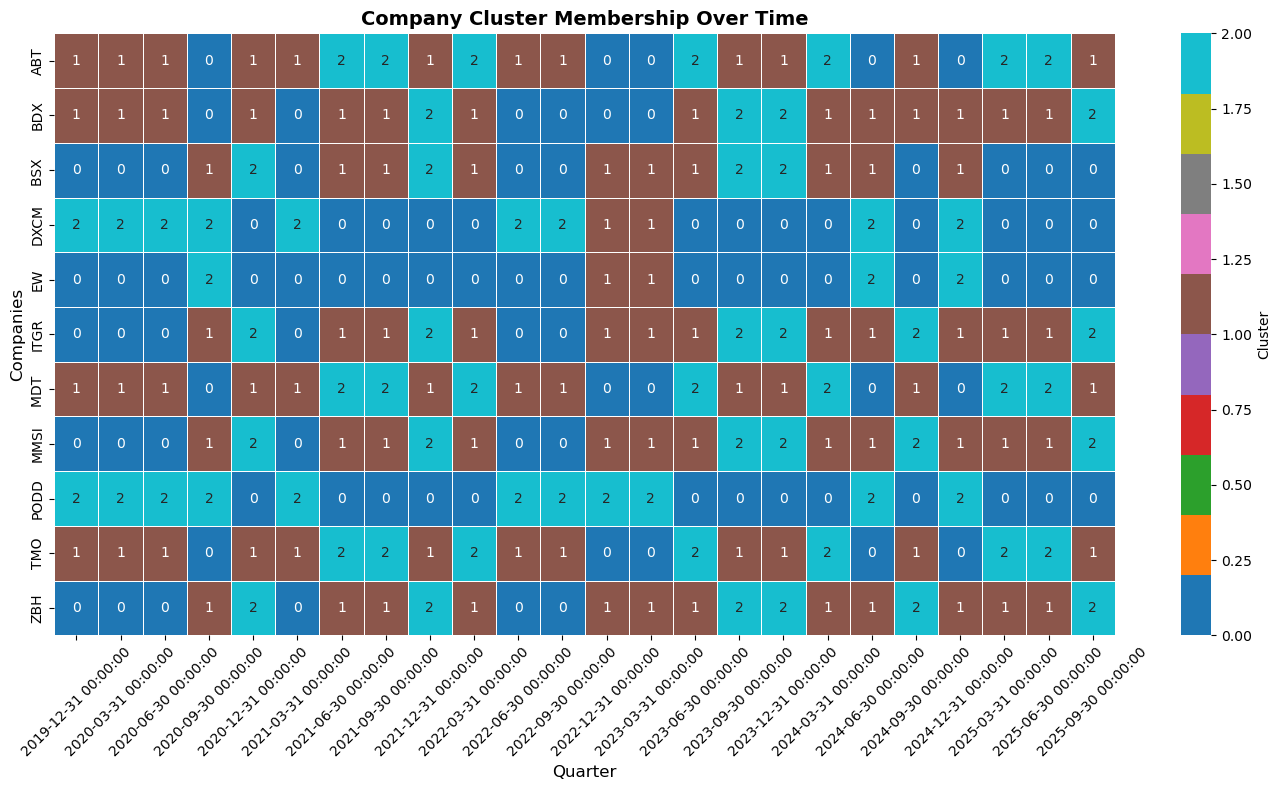

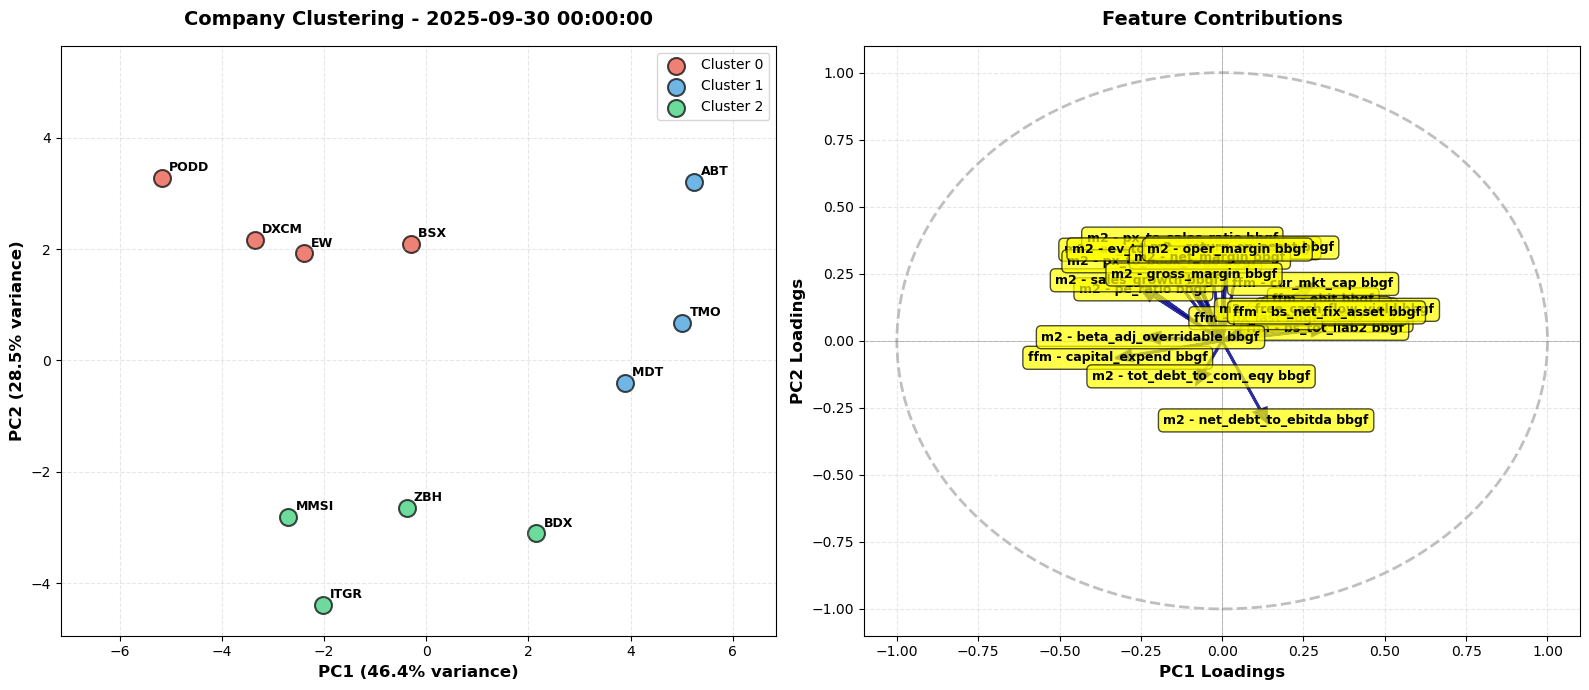


Animation saved → company_clustering_animation.gif


In [ ]:
# Cluster companies by PC1/PC2 scores each quarter
clustering_results = run_clustering_on_pca(pca_results, n_clusters=3, use_components=[1, 2])

# Measure how consistently each company stays in its cluster
stability = analyze_cluster_stability(clustering_results)

print("Cluster stability by company (1.0 = never changed cluster):")
print("-" * 55)
for ticker, metrics in sorted(stability.items(), key=lambda x: -x[1]['stability_ratio']):
    short = ticker.replace(' US Equity', '')
    print(f"  {short:<6}  stability={metrics['stability_ratio']:.2f}  "
          f"changes={metrics['cluster_changes']:>2} / {metrics['total_periods']} quarters")

# Heatmap: cluster membership over time
cluster_df = plot_cluster_transitions(clustering_results)

# Animated GIF of cluster evolution
animation_obj = create_animated_clustering(
    clustering_results,
    use_components=[1, 2],
    save_path='assets/company_clustering_animation.gif',
    interval=1500
)
print("\nAnimation saved → company_clustering_animation.gif")


## 5. Summary Statistics

The cells below surface the most and least stable companies from the clustering analysis —
a quick sanity check and a useful lead for further fundamental research:
- **Highly stable companies** are consistently in the same peer group → predictable positioning
- **Unstable companies** migrate between clusters → either improving/deteriorating fundamentals
  or noisy data worth investigating further


In [6]:
n_quarters = len(clustering_results)
stability_sorted = sorted(stability.items(), key=lambda x: x[1]['stability_ratio'], reverse=True)

print(f"Analysis covered {n_quarters} quarters\n")

print("Most stable companies (consistent peer group):")
for ticker, m in stability_sorted[:3]:
    print(f"  {ticker.replace(' US Equity', '')}: {m['stability_ratio']:.2f} stability ratio")

print("\nLeast stable companies (migrated between clusters):")
for ticker, m in stability_sorted[-3:]:
    print(f"  {ticker.replace(' US Equity', '')}: {m['stability_ratio']:.2f} stability ratio")


Analysis covered 24 quarters

Most stable companies (consistent peer group):
  EW: 0.65 stability ratio
  PODD: 0.61 stability ratio
  DXCM: 0.57 stability ratio

Least stable companies (migrated between clusters):
  ABT: 0.35 stability ratio
  MDT : 0.35 stability ratio
  TMO: 0.35 stability ratio


## Key Findings & Interpretation

### What PC1 Captures
Across most quarters, PC1 loads most heavily on **profitability and return metrics**
(Net Margin, ROA, ROE) — consistent with the academic literature where the first
principal component of fundamental data often acts as a *quality* or *size* factor.
This means the PCA is not just a dimensionality-reduction trick; it is extracting
an economically meaningful signal.

### Cluster Interpretation
The three K-Means clusters broadly correspond to:

| Cluster | Typical Profile |
|---------|----------------|
| **High-quality leaders** | High PC1 score — top profitability, strong returns, efficient operations |
| **Mid-tier / transitional** | Average PC1, mixed PC2 — companies in the middle of the quality spectrum |
| **Laggards / turnaround candidates** | Low PC1 — weaker margins, lower returns |

### Stability Insight
Companies with high stability ratios have **durable competitive moats** — their
relative position in the peer group does not erode quarter to quarter.
Companies with low stability ratios warrant closer scrutiny: they may be
undergoing a genuine strategic shift, or their fundamentals may be more volatile.

### Investment Thesis Link
When Abbott consistently appears in the high-quality cluster with a stable membership
ratio, it provides **quantitative corroboration** that Abbott's positioning is not a
one-quarter anomaly — it reflects a structurally superior fundamental profile
relative to the peer group.

---

## Methodology Notes

- **Standardisation:** Z-score normalisation applied per quarter before PCA (zero mean, unit variance)
- **PCA solver:** Full SVD; 3 components retained
- **Clustering:** K-Means (k=3), fitted on PC1+PC2 scores; random seed fixed for reproducibility
- **Stability metric:** Fraction of quarters where a company's cluster assignment equals its modal cluster
- **Data source:** Bloomberg Terminal (Quarterly Fundamentals)
- **Universe:** 11 medical device companies | **Helper functions:** `functions_preprocessing.py`
